<h1 style="text-align:center;"><b>ECG Multi-Level Classification (PyTorch version)</b></h1>

This notebook is a line-by-line PyTorch conversion of the original TensorFlow/Keras notebook. Every cell that touched TensorFlow has been rewritten; cells that were already framework-agnostic (pandas, numpy, wfdb, scipy, sklearn) are unchanged.

# Dataset Download and Project Structure

(Unchanged from the original — see the TensorFlow notebook for the PhysioNet PTB-XL download instructions and folder layout.)

In [5]:
# Import libraries
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import wfdb
import ast

from scipy.signal import butter, filtfilt, iirnotch
from sklearn.preprocessing import LabelEncoder

# One thing PyTorch doesn't auto-pick for you: the device.
# This checks for a GPU and falls back to CPU if there isn't one.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [6]:
print("PyTorch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.13.0+cpu
CUDA version: None
CUDA available: False


In [4]:
import torch

print(torch.cuda.is_available())

True


In [7]:
print("PyTorch version:", torch.__version__)
print("CUDA version in PyTorch:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.13.0+cpu
CUDA version in PyTorch: None
CUDA available: False


In [8]:
print(torch.version.cuda)

None


In [9]:
pip show torch

Name: torch
Version: 2.13.0
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License-Expression: Apache-2.0 AND Apache-2.0 WITH LLVM-exception AND BSD-2-Clause AND BSD-3-Clause AND BSL-1.0 AND MIT
Location: C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages
Requires: filelock, fsspec, jinja2, networkx, setuptools, sympy, typing-extensions
Required-by: executorch, torchvision
Note: you may need to restart the kernel to use updated packages.


Loading Metadata

# Dataset Download and Project Structure

## Dataset

Download the **PTB-XL ECG Dataset** from PhysioNet:

https://physionet.org/content/ptb-xl/1.0.2/

After downloading and extracting the dataset, organize the project with the following structure:

```
ecg_project/

├── data/
│   ├── ptbxl_database.csv
│   ├── scp_statements.csv
│   └── records500/
│       ├── 00000/
│       ├── 01000/
│       ├── 02000/
│       └── ...
│
├── ECG_classification.ipynb
```

### Directory Description

- **data/**  
  Contains all PTB-XL dataset files.

- **ptbxl_database.csv**  
  Contains metadata information for each ECG recording, including:
  - Patient information
  - Recording identifiers
  - Diagnostic labels
  - Dataset split information

- **scp_statements.csv**  
  Contains the SCP-ECG diagnostic statement mappings and descriptions.

- **records500/**  
  Contains the ECG signal recordings sampled at **500 Hz**.

- **ECG_classification.ipynb**  
  Jupyter Notebook 
 
```

In [40]:
print("Loading metadata...")

df = pd.read_csv(
    "data/ptbxl_database.csv",
    index_col="ecg_id"
)

df.scp_codes = df.scp_codes.apply(ast.literal_eval)

Loading metadata...


Load Diagnostic Mappings

In [41]:
scp_df = pd.read_csv(
    "data/scp_statements.csv",
    index_col=0
)

scp_df = scp_df[scp_df.diagnostic == 1]

<h2>Data Preprocessing</h2>

Convert SCP Codes to the 5 Superclasses

# ECG Diagnostic Classes

## 1. NORM — Normal ECG

Records showing no significant electrical abnormality — a structurally and electrically healthy heart rhythm and conduction pattern.

This is the majority class and serves as the baseline against which the other four diagnostic categories are compared.

---

## 2. MI — Myocardial Infarction

Myocardial infarction (acute or recent) refers to heart attack damage, where ECG changes reflect the death of heart muscle tissue due to blocked blood supply.

Subclasses distinguish infarction based on the anatomical location of the affected region of the heart:

- **IMI** — Inferior myocardial infarction
- **AMI** — Anterior myocardial infarction
- **LMI** — Lateral myocardial infarction
- **PMI** — Posterior myocardial infarction

This is clinically the most urgent category and is critical for **STEMI (ST-elevation myocardial infarction) alerts**, which require immediate medical intervention.

---

## 3. STTC — ST/T-Wave Changes

ST/T-wave changes include abnormalities in the ST-segment or T-wave portion of the ECG.

These changes may indicate:
- Reduced blood flow (ischemia) to heart muscle
- Electrolyte imbalances
- Other repolarization abnormalities

Subclasses include:

- **STTC** — General ST/T-wave changes
- **NST_** — Non-specific ST changes
- **ISC_** — Ischemic changes (various subtypes based on location)

This category represents ischemia-related warning signs, which may indicate earlier-stage or ongoing risk signals, unlike MI where tissue damage has already occurred.

---

## 4. CD — Conduction Disturbance

Conduction disturbances refer to abnormalities in how electrical signals travel through the heart's conduction system rather than damage to the heart muscle itself.

Subclasses include:

- **LBBB / RBBB** — Left and right bundle branch block
- **1AVB / 2AVB / 3AVB** — First-, second-, and third-degree atrioventricular block
- **IVCD** — Intraventricular conduction disturbance
- **WPW** — Wolff-Parkinson-White pattern (accessory conduction pathway)

These abnormalities are visible on ECG as changes in:
- QRS complex timing and morphology
- PR interval duration

---

## 5. HYP — Hypertrophy

Hypertrophy refers to enlargement or thickening of the heart muscle, most commonly involving the left ventricle.

Subclasses include:

- **LVH** — Left ventricular hypertrophy
- **RVH** — Right ventricular hypertrophy
- **LAO / LAE** — Left atrial overload/enlargement
- **RAO / RAE** — Right atrial overload/enlargement

Hypertrophy is commonly caused by chronic conditions such as:
- Hypertension
- Heart valve disease

These changes are visible on ECG through abnormal voltage amplitudes and other waveform characteristics.

In [42]:
def aggregate_superclasses(code_dict):

    classes = []

    for key in code_dict.keys():   # If not working, remove .keys()

        if key in scp_df.index:

            c = scp_df.loc[key, "diagnostic_class"]

            if pd.notna(c):
                classes.append(c)

    return list(set(classes))

In [43]:
df["superclasses"] = (
    df.scp_codes.apply(aggregate_superclasses)
)

Keep only records containing at least one superclass

In [44]:
df = df[df.superclasses.apply(len) > 0]

print("Total usable ECGs:", len(df))

Total usable ECGs: 21396


<h3>Multi-Hot Encoding</h3>

In [45]:
# Define the classes
CLASSES = [
    "NORM",
    "MI",
    "STTC",
    "CD",
    "HYP"
]

# Create a mapping:
CLASS_TO_IDX = {
    c: i for i, c in enumerate(CLASSES)
}

In [46]:
# Multi-Hot encoding function

def encode_labels(labels):

    y = np.zeros(len(CLASSES), dtype=np.float32)

    for label in labels:

        if label in CLASS_TO_IDX:
            y[CLASS_TO_IDX[label]] = 1.0

    return y

# <span style="color:red">Important</span>

In [47]:
SELECTED_LEADS = [0]   ## IMPORTANT: Check which lead should be selected based on how we use the 3 electrodes in our module

<h3>FILTERING FUNCTIONS</h3>

In [48]:
# Target sampling rate: we downsample the raw PTB-XL 500Hz recordings to
# 250Hz to match our wearable's operating rate, while keeping the window
# length at 10 seconds (2500 samples instead of 5000).
SOURCE_FS = 500
TARGET_FS = 250


def resample_ecg(signal, source_fs=SOURCE_FS, target_fs=TARGET_FS):
    """Downsamples `signal` (shape: (samples, leads)) from source_fs to
    target_fs using polyphase filtering. This applies the required
    anti-aliasing low-pass filter automatically before decimating, which
    avoids the aliasing artifacts a naive slice (e.g. signal[::2]) would
    introduce."""
    if source_fs == target_fs:
        return signal

    from scipy.signal import resample_poly
    return resample_poly(signal, target_fs, source_fs, axis=0)





### Original Filter used in actual data

In [49]:
def dc_removal_filter(signal, alpha=0.0063):
    """
    Causal single-pole high-pass (baseline/DC removal), matching the
    on-device firmware exactly:
        baseline[n] = alpha * raw[n] + (1 - alpha) * baseline[n-1]
        centered[n] = raw[n] - baseline[n]
    baseline[0] is initialized to raw[0], matching `baselineInit` in the
    firmware. Implemented as an explicit sample-by-sample recursion (not
    filtfilt) since the deployed device only ever sees past+current
    samples in real time -- filtfilt would be non-causal and unrealistic.

    signal: shape (samples, leads)
    """
    baseline = signal[0, :].copy()
    output = np.zeros_like(signal)
    for n in range(signal.shape[0]):
        baseline = alpha * signal[n, :] + (1 - alpha) * baseline
        output[n, :] = signal[n, :] - baseline
    return output

### Faster vectorized version

In [50]:
from scipy.signal import lfilter

def dc_removal_filter_fast(signal, alpha=0.0063):
    """
    Same causal single-pole DC-removal filter as dc_removal_filter(),
    but computed via scipy.signal.lfilter for speed instead of a
    per-sample Python loop. Numerically equivalent.
    signal: shape (samples, leads)
    """
    baseline = lfilter([alpha], [1, -(1 - alpha)], signal, axis=0)
    return signal - baseline

### Use the below functions only if necessary

In [51]:
# Use only if necessary
def bandpass_filter(signal, fs=TARGET_FS):

    lowcut = 0.5
    highcut = 40.0

    nyquist = fs / 2

    b, a = butter(            # Butterworth filter (IIR)
        4,
        [lowcut / nyquist, highcut / nyquist],
        btype='band'
    )

    return filtfilt(b, a, signal, axis=0)

In [52]:
# Use only if necessary

def notch_filter(signal, fs=TARGET_FS):

    b, a = iirnotch(
        50,     # 50 Hz mains frequency
        30,     # Quality factor
        fs
    )

    return filtfilt(b, a, signal, axis=0)


<H3>Visualize one ECG before and after preprocessing</H3>

Labels: ['NORM']
[[-0.11 ]
 [-0.11 ]
 [-0.11 ]
 ...
 [-0.095]
 [-0.095]
 [-0.095]]


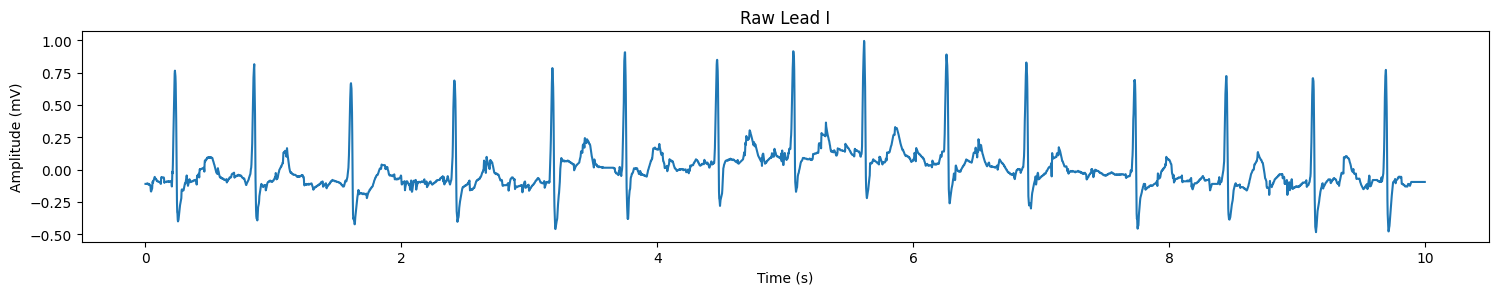

In [53]:
import matplotlib.pyplot as plt

sample_row = df.iloc[2000]

path = f"data/{sample_row.filename_hr}"

print("Labels:", sample_row.superclasses)

signal_raw, meta = wfdb.rdsamp(path)

# Select only the required leads
signal_raw = signal_raw[:, SELECTED_LEADS]

fs = SOURCE_FS   # raw PTB-XL files are still 500Hz on disk
t = np.arange(signal_raw.shape[0]) / fs

lead_names = ["Lead I"]

# Plot raw ECG
plt.figure(figsize=(15, 8))

print(signal_raw)

for i in range(1):

    plt.subplot(3, 1, i + 1)

    plt.plot(t, signal_raw[:, i])

    plt.title(f"Raw {lead_names[i]}")

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (mV)")

plt.tight_layout()
plt.show()


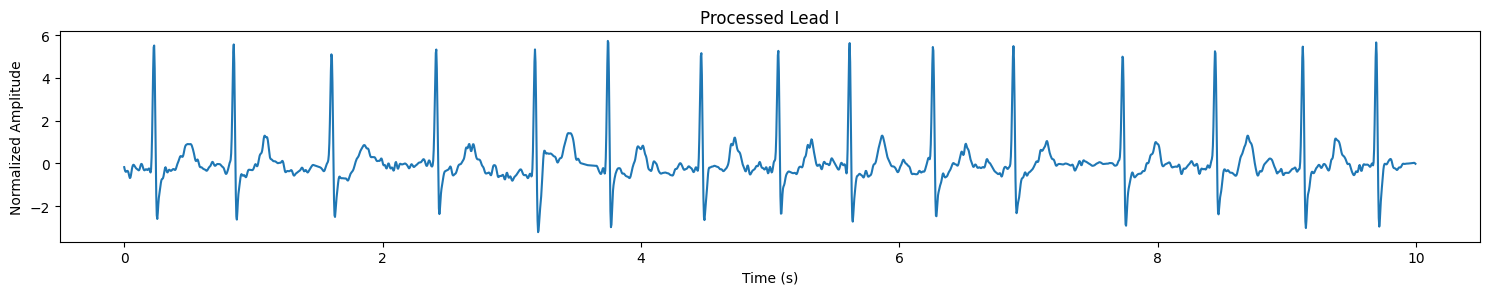

In [48]:
# After preprocessing

# Apply preprocessing manually (mirrors preprocess_ecg below)
signal_resampled = resample_ecg(signal_raw)   # 500Hz/5000 samples -> 250Hz/2500 samples

siganl_processed = dc_removal_filter(signal_resampled)

# signal_processed = bandpass_filter(signal_resampled)
# signal_processed = notch_filter(signal_processed)

mean = signal_processed.mean(axis=0)
std = signal_processed.std(axis=0)

signal_processed = (signal_processed - mean) / std

# Time axis for the resampled/processed signal (250Hz instead of 500Hz)
t_processed = np.arange(signal_processed.shape[0]) / TARGET_FS

# Plot processed ECG
plt.figure(figsize=(15, 8))

for i in range(1):

    plt.subplot(3, 1, i + 1)

    plt.plot(t_processed, signal_processed[:, i])

    plt.title(f"Processed {lead_names[i]}")

    plt.xlabel("Time (s)")
    plt.ylabel("Normalized Amplitude")

plt.tight_layout()
plt.show()


<H3>ECG PREPROCESSING</H3>

In [49]:
def preprocess_ecg(path):

    signal, meta = wfdb.rdsamp(path)

    # Select only required leads
    signal = signal[:, SELECTED_LEADS]

    # Resample from the raw 500Hz PTB-XL rate down to our target 250Hz
    # (still a 10-second window, now 2500 samples instead of 5000)
    signal = resample_ecg(signal)

    # Bandpass filtering
    signal = bandpass_filter(signal)

    # Notch filtering
    signal = notch_filter(signal)

    # Per-record z-score normalization
    mean = signal.mean(axis=0)
    std = signal.std(axis=0)

    std[std == 0] = 1e-8

    signal = (signal - mean) / std

    return signal.astype(np.float32)


<h4>DATASET CREATION</h4>

In [50]:
def build_dataset(dataframe):

    X = []
    Y = []

    total = len(dataframe)

    for idx, (_, row) in enumerate(dataframe.iterrows()):

        if idx % 500 == 0:
            print(f"{idx}/{total}")

        path = f"data/{row.filename_hr}"

        signal = preprocess_ecg(path)

        label = encode_labels(row.superclasses)

        X.append(signal)
        Y.append(label)

    X = np.array(X, dtype=np.float32)
    Y = np.array(Y, dtype=np.float32)

    return X, Y

<h4>TRAIN / VALIDATION / TEST SPLITS</h4>

In [51]:
train_df = df[df.strat_fold <= 8]

val_df = df[df.strat_fold == 9]

test_df = df[df.strat_fold == 10]

print("\nTrain:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Train: 17090
Validation: 2147
Test: 2159


<h3>Check Class Distribution</h3>

In [52]:
from collections import Counter

counter = Counter()

for labels in train_df["superclasses"]:
    counter.update(labels)

print("\nTraining Set Class Distribution")

for c in CLASSES:
    print(f"{c:5s}: {counter[c]}")


Training Set Class Distribution
NORM : 7598
MI   : 4381
STTC : 4188
CD   : 3909
HYP  : 2119


<h3>Compute class weights</h3>

In [53]:
total_samples = len(train_df)

class_weights = {}

print("\nClass Weights")

for c in CLASSES:

    weight = total_samples / (len(CLASSES) * counter[c])

    class_weights[c] = weight

    print(f"{c:5s}: {weight:.3f}")


Class Weights
NORM : 0.450
MI   : 0.780
STTC : 0.816
CD   : 0.874
HYP  : 1.613


In [54]:
# Convert to a PyTorch tensor
# (this is the only line that changes here: tf.constant -> torch.tensor,
# and we move it to whichever device we're training on)

CLASS_WEIGHT_VECTOR = torch.tensor(
    [class_weights[c] for c in CLASSES],
    dtype=torch.float32
).to(device)

print(CLASS_WEIGHT_VECTOR)

tensor([0.4499, 0.7802, 0.8161, 0.8744, 1.6130], device='cuda:0')


### Build Numpy arrays

In [55]:
print("\nBuilding training set...")
X_train, y_train = build_dataset(train_df)

print("\nBuilding validation set...")
X_val, y_val = build_dataset(val_df)

print("\nBuilding test set...")
X_test, y_test = build_dataset(test_df)


Building training set...
0/17090
500/17090
1000/17090
1500/17090
2000/17090
2500/17090
3000/17090
3500/17090
4000/17090
4500/17090
5000/17090
5500/17090
6000/17090
6500/17090
7000/17090
7500/17090
8000/17090
8500/17090
9000/17090
9500/17090
10000/17090
10500/17090
11000/17090
11500/17090
12000/17090
12500/17090
13000/17090
13500/17090
14000/17090
14500/17090
15000/17090
15500/17090
16000/17090
16500/17090
17000/17090

Building validation set...
0/2147
500/2147
1000/2147
1500/2147
2000/2147

Building test set...
0/2159
500/2159
1000/2159
1500/2159
2000/2159


In [56]:
# CHECK SHAPES

print("\nShapes:")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


Shapes:
X_train: (17090, 2500, 1)
y_train: (17090, 5)
X_val: (2147, 2500, 1)
y_val: (2147, 5)
X_test: (2159, 2500, 1)
y_test: (2159, 5)


# PyTorch Datasets & DataLoaders

**Why this section looks different from the TF version, explained simply:**

- `tf.data.Dataset` and PyTorch's `Dataset` + `DataLoader` do the same job (batching, shuffling,
  feeding data to the model) but PyTorch splits it into two pieces: a `Dataset` (knows how to fetch
  one sample) and a `DataLoader` (wraps it to produce shuffled batches).
- **Channel order matters.** Keras `Conv1D` expects shape `(batch, length, channels)` — "channels-last".
  PyTorch `Conv1d` expects `(batch, channels, length)` — "channels-first". Our `X_train` arrays come out
  of `build_dataset` as `(N, 5000, 1)` (length, channels), so we transpose to `(N, 1, 5000)` before
  handing them to the model. This is the single most common bug when porting TF conv code to PyTorch,
  so it's worth remembering.
- `.prefetch(tf.data.AUTOTUNE)` has no direct PyTorch equivalent to configure by hand — the DataLoader's
  `num_workers` argument (background worker processes that prepare the next batch while the GPU is busy)
  gives you the same speed-up.

In [57]:
class ECGDataset(Dataset):
    """
    Wraps the (N, 2500, 1) numpy arrays produced by build_dataset().
    Converts to PyTorch's channels-first convention: (N, 1, 2500).
    """
    def __init__(self, X, Y):
        # X: (N, 2500, 1) -> (N, 1, 2500)
        self.X = torch.from_numpy(X).permute(0, 2, 1).float()
        self.Y = torch.from_numpy(Y).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


BATCH_SIZE = 32

train_dataset = ECGDataset(X_train, y_train)
val_dataset   = ECGDataset(X_val,   y_val)
test_dataset  = ECGDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("\nPreprocessing complete!")



Preprocessing complete!


<center><h1>ML Model Implementation</h1></center>

Keras models in the original notebook are built **functionally**: Call `layers.Conv1D(...)(x)`
and chain tensors together, and `model.fit()` handles the entire training loop (forward pass, loss,
backward pass, optimizer step, logging, early stopping).

PyTorch works differently in two ways that matter for the rest of this notebook:

1. **Models are Python classes.** Subclass `nn.Module`, define layers in `__init__`, and
   define how data flows through them in a `forward()` method. There's no separate "layers.Input" —
   the input shape is just whatever feed into `forward()`.
2. **There is no `.fit()`.** Write the training loop manually: for each batch, run the model
   forward, compute the loss, call `loss.backward()` to get gradients, and `optimizer.step()` to
   update weights. This is more code, but it's *the same loop for every model in this notebook*, so
   we only have to write it once (see `train_model()` below) and reuse it for Models A, B, and C —
   mirroring `model.fit(...)` being called three times in the original.

## Custom weighted binary cross-entropy loss

**Use this loss function for all 3 models if the accuracy of the models are less due to the imbalance of the data set.**

In [10]:
def weighted_binary_crossentropy(y_pred_probs, y_true):
    """
    y_pred_probs: model output AFTER sigmoid, shape (batch, 5)
    y_true:       ground-truth multi-hot labels, shape (batch, 5)
    Equivalent to the Keras version: elementwise BCE, weighted per class,
    then averaged.
    """
    bce = F.binary_cross_entropy(y_pred_probs, y_true, reduction='none')
    return (bce * CLASS_WEIGHT_VECTOR).mean()

# Model Architectures

## Model A (ResNet-1D)

1D ResNets are a standard, heavily-used baseline for physiological signal classification (ECG, EEG, PPG).

Residual connections matter here because a plain deep CNN on a 5000-sample signal would suffer from vanishing gradients; skip connections fix that. This is a solid, fast baseline.

---

## Model B (ResNet + BiLSTM)

This is a well-known CNN-LSTM pattern: convolutional layers extract local morphological features (QRS shape, wave amplitudes), then the BiLSTM models how these features evolve and relate across time.

Useful for rhythm-based abnormalities that unfold over the full 10-second window rather than a single beat. This combination appears frequently in ECG arrhythmia literature.

---

## Model C (ResNet + Self-Attention)

Same ResNet stem, but a Transformer-style self-attention stack replaces the BiLSTM to model long-range temporal relationships.

<h1>Model A: ResNet</h1>

### Residual block, PyTorch style

Same architecture as the Keras version: `Conv1D(k=7) -> BN -> ReLU -> Conv1D(k=5) -> BN -> Add(shortcut) -> ReLU`,
with a 1x1 projection conv on the shortcut when the channel count changes.

Two PyTorch-specific things to know:
- `padding='same'` isn't available in `nn.Conv1d` for the odd kernel sizes here in the same automatic way
  Keras does it, so we pass `padding=kernel_size // 2` by hand, which is equivalent for odd kernel sizes.
- Every PyTorch layer that has learnable weights (Conv1d, BatchNorm1d, LSTM, Linear...) must be created
  inside `__init__` and *assigned to `self.something`* — that's how PyTorch discovers which tensors are
  trainable parameters. Contrast this with Keras where you just call `layers.Conv1D(...)` inline.

In [11]:
class ResidualBlock1D(nn.Module):
    """
    Conv1D(k=7) -> BN -> ReLU -> Conv1D(k=5) -> BN -> Add(shortcut) -> ReLU
    A 1x1 conv projects the shortcut when in_channels != out_channels.
    """
    def __init__(self, in_channels, out_channels, kernel_sizes=(7, 5)):
        super().__init__()
        k1, k2 = kernel_sizes

        self.conv1 = nn.Conv1d(in_channels, out_channels, k1, padding=k1 // 2)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, k2, padding=k2 // 2)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.project_shortcut = in_channels != out_channels
        if self.project_shortcut:
            self.shortcut_conv = nn.Conv1d(in_channels, out_channels, 1)
            self.shortcut_bn = nn.BatchNorm1d(out_channels)

    def forward(self, x):
        shortcut = x

        y = F.relu(self.bn1(self.conv1(x)))
        y = self.bn2(self.conv2(y))

        if self.project_shortcut:
            shortcut = self.shortcut_bn(self.shortcut_conv(shortcut))

        return F.relu(y + shortcut)


def make_residual_stage(in_channels, out_channels, n_blocks=2):
    """Stack `n_blocks` residual blocks. First block changes the channel count,
    the rest keep it fixed (in == out)."""
    blocks = [ResidualBlock1D(in_channels, out_channels)]
    for _ in range(n_blocks - 1):
        blocks.append(ResidualBlock1D(out_channels, out_channels))
    return nn.Sequential(*blocks)

Full Model

In [12]:
class ResNet1D(nn.Module):
    def __init__(self, in_channels=1, num_classes=5):
        super().__init__()

        # Stem
        self.stem_conv = nn.Conv1d(in_channels, 64, kernel_size=15, stride=2, padding=7)
        self.stem_bn = nn.BatchNorm1d(64)

        # Stage 1: 64 channels
        self.stage1 = make_residual_stage(64, 64, n_blocks=2)
        self.pool1 = nn.MaxPool1d(2)

        # Stage 2: 128 channels
        self.stage2 = make_residual_stage(64, 128, n_blocks=2)
        self.pool2 = nn.MaxPool1d(2)

        # Stage 3: 256 channels
        self.stage3 = make_residual_stage(128, 256, n_blocks=2)
        self.pool3 = nn.MaxPool1d(2)

        # Stage 4: 512 channels
        self.stage4 = make_residual_stage(256, 512, n_blocks=2)

        # Head
        self.fc1 = nn.Linear(512, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc_out = nn.Linear(256, num_classes)

    def forward(self, x):
        # x: (batch, 1, 2500)
        x = F.relu(self.stem_bn(self.stem_conv(x)))

        x = self.stage1(x)
        x = self.pool1(x)

        x = self.stage2(x)
        x = self.pool2(x)

        x = self.stage3(x)
        x = self.pool3(x)

        x = self.stage4(x)

        # GlobalAveragePooling1D equivalent: mean over the length dimension
        x = x.mean(dim=2)          # (batch, 512)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc_out(x))   # sigmoid output, same as Keras version
        return x


<h4>Build the model</h4>

In [105]:
NUM_CLASSES = 5

model_A = ResNet1D(in_channels=1, num_classes=NUM_CLASSES).to(device)

optimizer_A = torch.optim.Adam(model_A.parameters(), lr=1e-4)

# loss_fn = F.binary_cross_entropy   # later swap to loss_fn = weighted_binary_crossentropy in case of an imbalance
loss_fn = weighted_binary_crossentropy

Compile the model

**No PyTorch equivalent needed here.** Keras' `.compile()` bundles the optimizer, loss, and metrics
onto the model object. In PyTorch these three things just stay as separate Python variables
(`model_A`, `optimizer_A`, `loss_fn`) that you pass into the training loop yourself — nothing to
"compile". `model_A.summary()` also has no built-in equivalent; the closest thing is just printing
the model (`print(model_A)`), or installing the optional `torchinfo` package for a Keras-style summary
table.

In [68]:
print(model_A)

# Optional: pip install torchinfo, then:
# from torchinfo import summary
# summary(model_A, input_size=(BATCH_SIZE, 1, 5000))

ResNet1D(
  (stem_conv): Conv1d(1, 64, kernel_size=(15,), stride=(2,), padding=(7,))
  (stem_bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stage1): Sequential(
    (0): ResidualBlock1D(
      (conv1): Conv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(3,))
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ResidualBlock1D(
      (conv1): Conv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(3,))
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, d

In [63]:
pip install torchinfo

Note: you may need to restart the kernel to use updated packages.


In [69]:
from torchinfo import summary
summary(model_A, input_size=(BATCH_SIZE, 1, 2500))


Layer (type:depth-idx)                   Output Shape              Param #
ResNet1D                                 [32, 5]                   --
├─Conv1d: 1-1                            [32, 64, 1250]            1,024
├─BatchNorm1d: 1-2                       [32, 64, 1250]            128
├─Sequential: 1-3                        [32, 64, 1250]            --
│    └─ResidualBlock1D: 2-1              [32, 64, 1250]            --
│    │    └─Conv1d: 3-1                  [32, 64, 1250]            28,736
│    │    └─BatchNorm1d: 3-2             [32, 64, 1250]            128
│    │    └─Conv1d: 3-3                  [32, 64, 1250]            20,544
│    │    └─BatchNorm1d: 3-4             [32, 64, 1250]            128
│    └─ResidualBlock1D: 2-2              [32, 64, 1250]            --
│    │    └─Conv1d: 3-5                  [32, 64, 1250]            28,736
│    │    └─BatchNorm1d: 3-6             [32, 64, 1250]            128
│    │    └─Conv1d: 3-7                  [32, 64, 1250]           

<h3>Train the model</h3>

**This is the biggest structural change from the TF notebook.** Keras' `model.fit(...)` hides the
training loop, early stopping, and LR scheduling inside one call. In PyTorch we write a small
reusable `train_model()` function that does the same three jobs `model.fit()` did:

1. Loop over epochs, and within each epoch loop over batches from the `DataLoader`.
2. Track `val_auc` (AUC on the validation set) each epoch, remember the best weights seen so far,
   and stop early if it hasn't improved in `patience` epochs — this replicates
   `EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True)`.
3. Use `torch.optim.lr_scheduler.ReduceLROnPlateau`, PyTorch's direct equivalent of Keras'
   `ReduceLROnPlateau` callback, watching `val_loss` with the same `factor=0.5, patience=4, min_lr=1e-6`.

We write this once and reuse it for Models A, B and C, exactly like `model.fit()` gets called three
times in the original notebook.

In [15]:
from sklearn.metrics import roc_auc_score

def run_epoch(model, loader, loss_fn, optimizer=None):
    """
    One pass over `loader`. If `optimizer` is given, this trains (backprop + weight update);
    if it's None, this only evaluates (used for validation/test).
    Returns: average loss, all true labels, all predicted probabilities.
    """
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    all_true, all_prob = [], []

    context = torch.enable_grad() if is_training else torch.no_grad()
    with context:
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            if is_training:
                optimizer.zero_grad()

            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)

            if is_training:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * X_batch.size(0)
            all_true.append(y_batch.detach().cpu().numpy())
            all_prob.append(y_pred.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    all_true = np.concatenate(all_true, axis=0)
    all_prob = np.concatenate(all_prob, axis=0)
    return avg_loss, all_true, all_prob


def train_model(model, train_loader, val_loader, optimizer, loss_fn,
                 epochs=50, patience=8, model_name="model"):
    """
    Mirrors Keras' model.fit(..., callbacks=[EarlyStopping(...), ReduceLROnPlateau(...)]).
    Monitors val AUC for early stopping (mode='max'), val loss for LR reduction.
    """
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=4, min_lr=1e-6
    )

    best_val_auc = -np.inf
    best_state = None
    epochs_without_improvement = 0
    history = {"loss": [], "val_loss": [], "val_auc": []}

    for epoch in range(1, epochs + 1):
        train_loss, _, _ = run_epoch(model, train_loader, loss_fn, optimizer)
        val_loss, val_true, val_prob = run_epoch(model, val_loader, loss_fn)

        # multi_label AUC, averaged across the 5 classes (same as Keras AUC(multi_label=True))
        try:
            val_auc = roc_auc_score(val_true, val_prob, average='macro')
        except ValueError:
            val_auc = float('nan')   # can happen early on if a class has no positives in val batch

        history["loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_auc"].append(val_auc)

        scheduler.step(val_loss)

        print(f"[{model_name}] Epoch {epoch:02d}/{epochs} "
              f"- loss: {train_loss:.4f} - val_loss: {val_loss:.4f} - val_auc: {val_auc:.4f}")

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch} (best val_auc={best_val_auc:.4f})")
                break

    # restore_best_weights=True equivalent
    if best_state is not None:
        model.load_state_dict(best_state)

    return history

In [14]:
EPOCHS = 50

history_A = train_model(
    model_A, train_loader, val_loader,
    optimizer_A, loss_fn,
    epochs=EPOCHS, patience=8, model_name="Model_A_ResNet"
)

NameError: name 'model_A' is not defined

<h1>Model B: ResNet + BiLSTM</h1>

The same Residual block above is used.

<h3>FULL MODEL: ResNet feature extractor + BiLSTM</h3>

**Note on `nn.LSTM` vs Keras `LSTM`:** PyTorch's `nn.LSTM` expects input shaped
`(batch, seq_len, features)` when `batch_first=True` — the same convention Keras uses, so no
transpose is needed here (only the *convolutional* layers needed the channels-first swap).
`bidirectional=True` is PyTorch's equivalent of wrapping a layer in `layers.Bidirectional(...)`.

In [16]:
class ResNetBiLSTM(nn.Module):
    def __init__(self, in_channels=1, num_classes=5):
        super().__init__()

        # Stem -- downsamples 2500 -> 1250
        self.stem_conv = nn.Conv1d(in_channels, 64, kernel_size=15, stride=2, padding=7)
        self.stem_bn = nn.BatchNorm1d(64)

        # Stage 1: 64 channels, downsample 1250 -> 625
        self.stage1 = make_residual_stage(64, 64, n_blocks=2)
        self.pool1 = nn.MaxPool1d(2)

        # Stage 2: 128 channels, downsample 625 -> 312
        self.stage2 = make_residual_stage(64, 128, n_blocks=2)
        self.pool2 = nn.MaxPool1d(2)

        # Stage 3: 256 channels, downsample 312 -> 156
        self.stage3 = make_residual_stage(128, 256, n_blocks=2)
        self.pool3 = nn.MaxPool1d(2)

        # NOTE: stopping conv downsampling here (unlike pure ResNet which had
        # a 4th 512-channel stage) -- same rationale as the original: 156
        # timesteps is a reasonable length to feed a BiLSTM.

        # ---- BiLSTM over the extracted feature sequence ----
        self.lstm1 = nn.LSTM(input_size=256, hidden_size=128, batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(input_size=256, hidden_size=64, batch_first=True, bidirectional=True)

        # ---- Classification head ----
        self.fc1 = nn.Linear(128, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x):
        # x: (batch, 1, 2500)
        x = F.relu(self.stem_bn(self.stem_conv(x)))

        x = self.stage1(x); x = self.pool1(x)
        x = self.stage2(x); x = self.pool2(x)
        x = self.stage3(x); x = self.pool3(x)
        # x: (batch, 256, 156) -- channels-first (conv convention)

        x = x.permute(0, 2, 1)   # -> (batch, 156, 256) -- sequence-first (LSTM convention)

        x, _ = self.lstm1(x)               # return_sequences=True equivalent: keep the full sequence
        x, (h_n, _) = self.lstm2(x)        # return_sequences=False equivalent: we only need the final state

        # h_n: (num_directions=2, batch, 64) for the last (2nd) LSTM layer.
        # Concatenate the forward and backward final hidden states, same as what
        # Keras' Bidirectional(..., return_sequences=False) returns.
        x = torch.cat([h_n[0], h_n[1]], dim=1)   # (batch, 128)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc_out(x))
        return x


<h3>Build the model</h3>

In [83]:
NUM_CLASSES = 5

model_B = ResNetBiLSTM(in_channels=1, num_classes=NUM_CLASSES).to(device)

optimizer_B = torch.optim.Adam(model_B.parameters(), lr=1e-4)

# loss_fn_B = F.binary_cross_entropy    # later swap to loss_fn = weighted_binary_crossentropy in case of an imbalance
loss_fn = weighted_binary_crossentropy

<h3>Compile the model</h3>

(No `.compile()` step needed in PyTorch — see the note under Model A.)

In [84]:
print(model_B)

ResNetBiLSTM(
  (stem_conv): Conv1d(1, 64, kernel_size=(15,), stride=(2,), padding=(7,))
  (stem_bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stage1): Sequential(
    (0): ResidualBlock1D(
      (conv1): Conv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(3,))
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ResidualBlock1D(
      (conv1): Conv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(3,))
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=

In [85]:
summary(model_B, input_size=(BATCH_SIZE, 1, 2500))


Layer (type:depth-idx)                   Output Shape              Param #
ResNetBiLSTM                             [32, 5]                   --
├─Conv1d: 1-1                            [32, 64, 1250]            1,024
├─BatchNorm1d: 1-2                       [32, 64, 1250]            128
├─Sequential: 1-3                        [32, 64, 1250]            --
│    └─ResidualBlock1D: 2-1              [32, 64, 1250]            --
│    │    └─Conv1d: 3-1                  [32, 64, 1250]            28,736
│    │    └─BatchNorm1d: 3-2             [32, 64, 1250]            128
│    │    └─Conv1d: 3-3                  [32, 64, 1250]            20,544
│    │    └─BatchNorm1d: 3-4             [32, 64, 1250]            128
│    └─ResidualBlock1D: 2-2              [32, 64, 1250]            --
│    │    └─Conv1d: 3-5                  [32, 64, 1250]            28,736
│    │    └─BatchNorm1d: 3-6             [32, 64, 1250]            128
│    │    └─Conv1d: 3-7                  [32, 64, 1250]           

<h3>Train the model</h3>

In [86]:
EPOCHS = 50

history_B = train_model(
    model_B, train_loader, val_loader,
    optimizer_B, loss_fn_B,
    epochs=EPOCHS, patience=8, model_name="Model_B_ResNet_BiLSTM"
)

[Model_B_ResNet_BiLSTM] Epoch 01/50 - loss: 0.4734 - val_loss: 0.4160 - val_auc: 0.8033
[Model_B_ResNet_BiLSTM] Epoch 02/50 - loss: 0.4289 - val_loss: 0.4168 - val_auc: 0.8034
[Model_B_ResNet_BiLSTM] Epoch 03/50 - loss: 0.4186 - val_loss: 0.4082 - val_auc: 0.8104
[Model_B_ResNet_BiLSTM] Epoch 04/50 - loss: 0.4113 - val_loss: 0.4006 - val_auc: 0.8158
[Model_B_ResNet_BiLSTM] Epoch 05/50 - loss: 0.4090 - val_loss: 0.3992 - val_auc: 0.8150
[Model_B_ResNet_BiLSTM] Epoch 06/50 - loss: 0.4052 - val_loss: 0.3957 - val_auc: 0.8204
[Model_B_ResNet_BiLSTM] Epoch 07/50 - loss: 0.4029 - val_loss: 0.3970 - val_auc: 0.8222
[Model_B_ResNet_BiLSTM] Epoch 08/50 - loss: 0.4006 - val_loss: 0.3973 - val_auc: 0.8227
[Model_B_ResNet_BiLSTM] Epoch 09/50 - loss: 0.3991 - val_loss: 0.3979 - val_auc: 0.8239
[Model_B_ResNet_BiLSTM] Epoch 10/50 - loss: 0.3993 - val_loss: 0.3974 - val_auc: 0.8200
[Model_B_ResNet_BiLSTM] Epoch 11/50 - loss: 0.3989 - val_loss: 0.3937 - val_auc: 0.8210
[Model_B_ResNet_BiLSTM] Epoch 12

<h1>Model C: ResNet + Self-Attention (No LSTM)</h1>

The same Residual block above is used.

<h3>POSITIONAL ENCODING (sinusoidal, as in the original Transformer)</h3>

In [17]:
def positional_encoding(seq_len, d_model, device=device):
    positions = np.arange(seq_len)[:, np.newaxis]
    dims = np.arange(d_model)[np.newaxis, :]

    angle_rates = 1 / np.power(10000, (2 * (dims // 2)) / np.float32(d_model))
    angle_rads = positions * angle_rates

    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    pe = torch.tensor(angle_rads[np.newaxis, ...], dtype=torch.float32)  # (1, seq_len, d_model)
    return pe.to(device)

<h3>TRANSFORMER-STYLE ENCODER BLOCK (self-attention + feed-forward)</h3>

**Note on `nn.MultiheadAttention`:** by default it expects `(seq_len, batch, features)`. We pass
`batch_first=True` at construction time so it matches Keras' `(batch, seq_len, features)` convention
and no extra transposing is needed here.

In [18]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads=4, ff_dim=256, dropout=0.1):
        super().__init__()
        self.mha = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads,
                                          dropout=dropout, batch_first=True)
        self.dropout1 = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        self.ffn1 = nn.Linear(d_model, ff_dim)
        self.ffn2 = nn.Linear(ff_dim, d_model)
        self.dropout2 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x):
        # Multi-head self-attention with residual connection
        attn_out, _ = self.mha(x, x, x)   # query=x, key=x, value=x -> self-attention
        x = self.norm1(x + self.dropout1(attn_out))

        # Feed-forward network with residual connection
        ffn_out = self.ffn2(F.relu(self.ffn1(x)))
        x = self.norm2(x + self.dropout2(ffn_out))
        return x

<h3>FULL MODEL: ResNet feature extractor + Self-Attention</h3>

In [19]:
class ResNetAttention(nn.Module):
    def __init__(self, in_channels=1, num_classes=5,
                 d_model=256, num_heads=4, num_transformer_blocks=2):
        super().__init__()
        self.d_model = d_model

        # Stem -- downsamples 2500 -> 1250
        self.stem_conv = nn.Conv1d(in_channels, 64, kernel_size=15, stride=2, padding=7)
        self.stem_bn = nn.BatchNorm1d(64)

        # Stage 1: 64 channels, downsample 1250 -> 625
        self.stage1 = make_residual_stage(64, 64, n_blocks=2)
        self.pool1 = nn.MaxPool1d(2)

        # Stage 2: 128 channels, downsample 625 -> 312
        self.stage2 = make_residual_stage(64, 128, n_blocks=2)
        self.pool2 = nn.MaxPool1d(2)

        # Stage 3: 256 channels (= d_model), downsample 312 -> 156
        self.stage3 = make_residual_stage(128, 256, n_blocks=2)
        self.pool3 = nn.MaxPool1d(2)

        self.transformer_blocks = nn.ModuleList([
            TransformerEncoderBlock(d_model=d_model, num_heads=num_heads, ff_dim=512)
            for _ in range(num_transformer_blocks)
        ])

        self.fc1 = nn.Linear(d_model, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc_out = nn.Linear(128, num_classes)

        self._pe_cache = {}   # cache positional encodings per sequence length

    def forward(self, x):
        # x: (batch, 1, 2500)
        x = F.relu(self.stem_bn(self.stem_conv(x)))

        x = self.stage1(x); x = self.pool1(x)
        x = self.stage2(x); x = self.pool2(x)
        x = self.stage3(x); x = self.pool3(x)
        # x: (batch, 256, 156) -- channels-first (conv convention)

        x = x.permute(0, 2, 1)   # -> (batch, 156, 256) -- sequence-first (attention convention)
        seq_len = x.shape[1]

        if seq_len not in self._pe_cache:
            self._pe_cache[seq_len] = positional_encoding(seq_len, self.d_model, device=x.device)
        x = x + self._pe_cache[seq_len]

        for block in self.transformer_blocks:
            x = block(x)

        # GlobalAveragePooling1D equivalent: mean over the sequence dimension
        x = x.mean(dim=1)   # (batch, d_model)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc_out(x))     #x = self.fc_out(x)

        return x


<h3>Build the model</h3>

In [102]:
NUM_CLASSES = 5

model_C = ResNetAttention(in_channels=1, num_classes=NUM_CLASSES).to(device)

optimizer_C = torch.optim.Adam(model_C.parameters(), lr=1e-4)

# loss_fn = F.binary_cross_entropy    # later swap to loss_fn = weighted_binary_crossentropy in case of an imbalance
# criterion = nn.BCEWithLogitsLoss(pos_weight=...)

loss_fn = weighted_binary_crossentropy

<h3>Compile the model</h3>

(No `.compile()` step needed in PyTorch — see the note under Model A.)

In [93]:
print(model_C)

ResNetAttention(
  (stem_conv): Conv1d(1, 64, kernel_size=(15,), stride=(2,), padding=(7,))
  (stem_bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stage1): Sequential(
    (0): ResidualBlock1D(
      (conv1): Conv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(3,))
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ResidualBlock1D(
      (conv1): Conv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(3,))
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (pool1): MaxPool1d(kernel_size=2, stride=2, paddi

In [94]:
from torchinfo import summary
summary(model_C, input_size=(BATCH_SIZE, 1, 2500))


Layer (type:depth-idx)                   Output Shape              Param #
ResNetAttention                          [32, 5]                   --
├─Conv1d: 1-1                            [32, 64, 1250]            1,024
├─BatchNorm1d: 1-2                       [32, 64, 1250]            128
├─Sequential: 1-3                        [32, 64, 1250]            --
│    └─ResidualBlock1D: 2-1              [32, 64, 1250]            --
│    │    └─Conv1d: 3-1                  [32, 64, 1250]            28,736
│    │    └─BatchNorm1d: 3-2             [32, 64, 1250]            128
│    │    └─Conv1d: 3-3                  [32, 64, 1250]            20,544
│    │    └─BatchNorm1d: 3-4             [32, 64, 1250]            128
│    └─ResidualBlock1D: 2-2              [32, 64, 1250]            --
│    │    └─Conv1d: 3-5                  [32, 64, 1250]            28,736
│    │    └─BatchNorm1d: 3-6             [32, 64, 1250]            128
│    │    └─Conv1d: 3-7                  [32, 64, 1250]           

<h3>Train the model</h3>

In [103]:
EPOCHS = 50

history_C = train_model(
    model_C, train_loader, val_loader,
    optimizer_C, loss_fn,
    epochs=EPOCHS, patience=8, model_name="Model_C_ResNet_Attention"
)

[Model_C_ResNet_Attention] Epoch 01/50 - loss: 0.3756 - val_loss: 0.3503 - val_auc: 0.8260
[Model_C_ResNet_Attention] Epoch 02/50 - loss: 0.3518 - val_loss: 0.3389 - val_auc: 0.8354
[Model_C_ResNet_Attention] Epoch 03/50 - loss: 0.3455 - val_loss: 0.3420 - val_auc: 0.8310
[Model_C_ResNet_Attention] Epoch 04/50 - loss: 0.3396 - val_loss: 0.3393 - val_auc: 0.8327
[Model_C_ResNet_Attention] Epoch 05/50 - loss: 0.3358 - val_loss: 0.3365 - val_auc: 0.8349
[Model_C_ResNet_Attention] Epoch 06/50 - loss: 0.3327 - val_loss: 0.3345 - val_auc: 0.8348
[Model_C_ResNet_Attention] Epoch 07/50 - loss: 0.3282 - val_loss: 0.3415 - val_auc: 0.8330
[Model_C_ResNet_Attention] Epoch 08/50 - loss: 0.3246 - val_loss: 0.3395 - val_auc: 0.8344
[Model_C_ResNet_Attention] Epoch 09/50 - loss: 0.3225 - val_loss: 0.3358 - val_auc: 0.8353
[Model_C_ResNet_Attention] Epoch 10/50 - loss: 0.3190 - val_loss: 0.3451 - val_auc: 0.8334
Early stopping at epoch 10 (best val_auc=0.8354)


<h2>Thresholding sigmoid outputs to binary predictions</h2>

`model.predict(...)` doesn't exist in PyTorch — the equivalent is: set `model.eval()` (turns off
dropout/batch-norm training behaviour), wrap the forward pass in `torch.no_grad()` (skips building the
backward-pass graph, since we're not training), then call `model(X)` directly.

In [20]:
THRESHOLD = 0.5
LABEL_NAMES = ["NORM", "MI", "STTC", "CD", "HYP"]

# Function to call on an entire data set
def get_predictions(model, loader, threshold=THRESHOLD):
    """
    Runs the model on a PyTorch DataLoader, returns:
    - y_true: ground-truth labels (N, 5)
    - y_prob: raw sigmoid outputs (N, 5)
    - y_pred: thresholded binary predictions (N, 5)
    """
    model.eval()
    y_true, y_prob = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            preds = model(X_batch)
            y_prob.append(preds.cpu().numpy())
            y_true.append(y_batch.numpy())

    y_true = np.concatenate(y_true, axis=0)
    y_prob = np.concatenate(y_prob, axis=0)
    y_pred = (y_prob >= threshold).astype(int)

    return y_true, y_prob, y_pred


# Function to call on a single data (one ECG signal)
# NOTE: Model expects the input shape (batch_size, 1, 2500) -- channels-first
def predict_single(model, signal, label_names=LABEL_NAMES, threshold=THRESHOLD):
    """
    signal: raw ECG signal, already preprocessed at 250Hz, shape (2500, 1) or (2500,)
    Returns: list of predicted label names, plus the raw probabilities
    """
    model.eval()

    signal = np.asarray(signal)
    if signal.ndim == 1:
        signal = signal.reshape(-1, 1)          # (2500,) -> (2500, 1)

    # (2500, 1) -> (1, 1, 2500): add batch dim, then permute to channels-first
    signal_batch = torch.from_numpy(signal).float().unsqueeze(0).permute(0, 2, 1).to(device)

    with torch.no_grad():
        y_prob = model(signal_batch).cpu().numpy()   # shape (1, 5)
    y_pred = (y_prob >= threshold).astype(int)         # shape (1, 5)

    y_prob = y_prob[0]      # shape (5,)
    y_pred = y_pred[0]      # shape (5,)

    predicted_labels = [label_names[i] for i in range(len(y_pred)) if y_pred[i] == 1]

    return predicted_labels, y_prob, y_pred


def final_output_on_single_data(predicted_labels):
    """Return the label as a string.
        If predicted_labels is empty => label = "UNKNOWN"
        If predicted_labels contains "NORM" + any other label => label = "UNKNOWN"
    Arg:
        predicted_labels (list): predicted label names, e.g. ['MI', 'NORM']
    Return:
        label (str): Label of the signal
    """
    if len(predicted_labels) == 0:
        label = "UNKNOWN"
    elif "NORM" in predicted_labels and len(predicted_labels) > 1:
        label = "UNKNOWN"
    else:
        label = ', '.join(predicted_labels)

    return label


### Thershold tunning

In [114]:
from sklearn.metrics import f1_score, fbeta_score


def find_best_thresholds(y_true, y_prob, label_names, metric="f1", beta=2.0, thresholds=None):
    """
    Finds the per-class threshold that maximizes `metric`, evaluated on
    whatever (y_true, y_prob) you pass in -- run this on the VALIDATION
    set only. Tuning on the test set would leak test information into
    your model-selection decision.

    metric:
        "f1"    -> balanced precision/recall (sklearn's default F1)
        "fbeta" -> recall-weighted via `beta` (beta=2.0 favors recall over
                   precision -- useful for classes like MI/HYP, where a
                   missed positive is costlier than a false alarm)

    Returns:
        best_thresholds: dict {label_name: best_threshold}
        best_scores:     dict {label_name: best_metric_value_at_that_threshold}
    """
    if thresholds is None:
        thresholds = np.arange(0.01, 1.00, 0.01)

    best_thresholds = {}
    best_scores = {}

    for i, label in enumerate(label_names):
        y_true_c = y_true[:, i]
        y_prob_c = y_prob[:, i]

        scores = []
        for t in thresholds:
            y_pred_c = (y_prob_c >= t).astype(int)
            if metric == "fbeta":
                score = fbeta_score(y_true_c, y_pred_c, beta=beta, zero_division=0)
            else:
                score = f1_score(y_true_c, y_pred_c, zero_division=0)
            scores.append(score)

        best_idx = int(np.argmax(scores))
        best_thresholds[label] = float(thresholds[best_idx])
        best_scores[label] = float(scores[best_idx])

    return best_thresholds, best_scores


def apply_thresholds(y_prob, thresholds_dict, label_names):
    """
    Applies a per-class threshold vector to raw probabilities.
    thresholds_dict: {label_name: threshold}, e.g. output of find_best_thresholds
    Returns y_pred: (N, num_labels) binary array
    """
    threshold_vector = np.array([thresholds_dict[label] for label in label_names])
    return (y_prob >= threshold_vector[np.newaxis, :]).astype(int)

In [121]:
def find_best_thresholds_constrained(y_true, y_prob, label_names,
                                       recall_biased_labels=("MI", "HYP"),
                                       min_precision=0.40,
                                       thresholds=None):
    """
    For labels in recall_biased_labels: maximize recall subject to
    precision >= min_precision. If no threshold meets the precision
    floor, falls back to the precision-maximizing threshold (best
    available option) and flags it.
    For all other labels: maximize plain F1, same as before.
    """
    from sklearn.metrics import precision_score, recall_score

    if thresholds is None:
        thresholds = np.arange(0.01, 1.00, 0.01)

    best_thresholds = {}
    best_scores = {}

    for i, label in enumerate(label_names):
        y_true_c = y_true[:, i]
        y_prob_c = y_prob[:, i]

        if label in recall_biased_labels:
            best_t, best_recall, best_prec = None, -1, None
            for t in thresholds:
                y_pred_c = (y_prob_c >= t).astype(int)
                prec = precision_score(y_true_c, y_pred_c, zero_division=0)
                rec = recall_score(y_true_c, y_pred_c, zero_division=0)
                if prec >= min_precision and rec > best_recall:
                    best_t, best_recall, best_prec = t, rec, prec

            if best_t is None:
                # no threshold hits the precision floor -- fall back to
                # whichever threshold gives the best precision available
                precisions = [precision_score(y_true_c, (y_prob_c >= t).astype(int), zero_division=0)
                              for t in thresholds]
                best_idx = int(np.argmax(precisions))
                best_t = float(thresholds[best_idx])
                best_recall = recall_score(y_true_c, (y_prob_c >= best_t).astype(int), zero_division=0)
                print(f"  [warning] {label}: no threshold reached "
                      f"precision >= {min_precision}; using best-available "
                      f"threshold {best_t:.2f} instead")

            best_thresholds[label] = float(best_t)
            best_scores[label] = float(best_recall)  # storing recall here since that's what we optimized

        else:
            scores = []
            for t in thresholds:
                y_pred_c = (y_prob_c >= t).astype(int)
                scores.append(f1_score(y_true_c, y_pred_c, zero_division=0))
            best_idx = int(np.argmax(scores))
            best_thresholds[label] = float(thresholds[best_idx])
            best_scores[label] = float(scores[best_idx])

    return best_thresholds, best_scores

<h2>Computing accuracy, precision, recall, F1</h2>

In [109]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, multilabel_confusion_matrix
)

In [110]:
def evaluate_multilabel(y_true, y_pred, label_names=None, set_name=""):
    """
    Prints subset accuracy, Hamming accuracy, and micro/macro
    precision/recall/F1, plus per-label breakdown.
    (Unchanged from the TF notebook -- this operates on numpy arrays
    and never touched TensorFlow in the first place.)
    """
    n_labels = y_true.shape[1]
    if label_names is None:
        label_names = [f"Label_{i}" for i in range(n_labels)]

    subset_acc = accuracy_score(y_true, y_pred)
    hamming_acc = (y_true == y_pred).mean()

    precision_micro = precision_score(y_true, y_pred, average='micro', zero_division=0)
    recall_micro    = recall_score(y_true, y_pred, average='micro', zero_division=0)
    f1_micro        = f1_score(y_true, y_pred, average='micro', zero_division=0)

    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_macro    = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro        = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"\n{'='*60}")
    print(f"Evaluation on: {set_name}")
    print(f"{'='*60}")
    print(f"Subset Accuracy (exact match): {subset_acc:.4f}")
    print(f"Hamming Accuracy (per-label):  {hamming_acc:.4f}")
    print(f"\n--- Micro-averaged (pools all labels together) ---")
    print(f"Precision: {precision_micro:.4f}")
    print(f"Recall:    {recall_micro:.4f}")
    print(f"F1 Score:  {f1_micro:.4f}")
    print(f"\n--- Macro-averaged (unweighted mean across labels) ---")
    print(f"Precision: {precision_macro:.4f}")
    print(f"Recall:    {recall_macro:.4f}")
    print(f"F1 Score:  {f1_macro:.4f}")
    print(f"\n--- Per-label breakdown ---")
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))

    return {
        'subset_accuracy': subset_acc,
        'hamming_accuracy': hamming_acc,
        'precision_micro': precision_micro,
        'recall_micro': recall_micro,
        'f1_micro': f1_micro,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
    }

<h3>Running this across all three models and all three splits</h3>

In [111]:
models_dict = {
    'Model_A_ResNet': model_A,
    'Model_B_ResNet_BiLSTM': model_B,
    'Model_C_ResNet_Attention': model_C,
}

loaders_dict = {
    'Train': train_loader,
    'Validation': val_loader,
    'Test': test_loader,
}

results = {}  # results[model_name][split_name] = metrics dict

for model_name, model in models_dict.items():
    results[model_name] = {}
    for split_name, loader in loaders_dict.items():
        y_true, y_prob, y_pred = get_predictions(model, loader)
        metrics_dict = evaluate_multilabel(
            y_true, y_pred,
            label_names=LABEL_NAMES,
            set_name=f"{model_name} — {split_name}"
        )
        results[model_name][split_name] = metrics_dict


Evaluation on: Model_A_ResNet — Train
Subset Accuracy (exact match): 0.5288
Hamming Accuracy (per-label):  0.8492

--- Micro-averaged (pools all labels together) ---
Precision: 0.7474
Recall:    0.6335
F1 Score:  0.6858

--- Macro-averaged (unweighted mean across labels) ---
Precision: 0.7522
Recall:    0.5580
F1 Score:  0.6082

--- Per-label breakdown ---
              precision    recall  f1-score   support

        NORM       0.79      0.85      0.82      7598
          MI       0.68      0.40      0.50      4381
        STTC       0.67      0.76      0.71      4188
          CD       0.81      0.56      0.66      3909
         HYP       0.81      0.22      0.35      2119

   micro avg       0.75      0.63      0.69     22195
   macro avg       0.75      0.56      0.61     22195
weighted avg       0.75      0.63      0.66     22195
 samples avg       0.68      0.66      0.66     22195


Evaluation on: Model_A_ResNet — Validation
Subset Accuracy (exact match): 0.4881
Hamming Accurac

### Test with tuned parameters

In [122]:
# ---------------------------------------------------------------------------
# Per-class threshold tuning: for each model, find the best threshold per
# class on VALIDATION, then apply those same thresholds when evaluating
# on Train/Validation/Test for a fair, honest final comparison.
# ---------------------------------------------------------------------------
tuned_thresholds = {}   # tuned_thresholds[model_name] = {label: threshold}
tuned_results = {}      # tuned_results[model_name][split_name] = metrics dict

for model_name, model in models_dict.items():

    # 1. Get raw probabilities on VALIDATION only -- this is what the
    #    thresholds get tuned against
    y_true_val, y_prob_val, _ = get_predictions(model, val_loader)

    # 2. Find best per-class thresholds (F1-optimal here; swap to
    #    metric="fbeta" for specific classes like MI/HYP if you want to
    #    bias toward recall -- see the per-label loop version discussed
    #    earlier)

    
    # best_thresholds, best_val_scores = find_best_thresholds_mixed(
    #     y_true_val, y_prob_val, LABEL_NAMES
    # )


    best_thresholds, best_val_scores = find_best_thresholds_constrained(
    y_true_val, y_prob_val, LABEL_NAMES,
    recall_biased_labels=("MI", "HYP"),
    min_precision=0.40   # tune this number to what you find acceptable
)
    
    tuned_thresholds[model_name] = best_thresholds

    print(f"\n{'='*60}")
    print(f"{model_name} — tuned thresholds (from validation)")
    print(f"{'='*60}")
    for label in LABEL_NAMES:
        print(f"  {label:5s}: threshold={best_thresholds[label]:.2f}  "
              f"(val F1={best_val_scores[label]:.4f})")

    # 3. Apply those SAME thresholds across Train/Validation/Test
    tuned_results[model_name] = {}
    for split_name, loader in loaders_dict.items():
        y_true, y_prob, _ = get_predictions(model, loader)
        y_pred_tuned = apply_thresholds(y_prob, best_thresholds, LABEL_NAMES)

        metrics_dict = evaluate_multilabel(
            y_true, y_pred_tuned,
            label_names=LABEL_NAMES,
            set_name=f"{model_name} — {split_name} (tuned thresholds)"
        )
        tuned_results[model_name][split_name] = metrics_dict


Model_A_ResNet — tuned thresholds (from validation)
  NORM : threshold=0.31  (val F1=0.8036)
  MI   : threshold=0.12  (val F1=0.8466)
  STTC : threshold=0.29  (val F1=0.6718)
  CD   : threshold=0.40  (val F1=0.6080)
  HYP  : threshold=0.21  (val F1=0.4403)

Evaluation on: Model_A_ResNet — Train (tuned thresholds)
Subset Accuracy (exact match): 0.3744
Hamming Accuracy (per-label):  0.7983

--- Micro-averaged (pools all labels together) ---
Precision: 0.5790
Recall:    0.8188
F1 Score:  0.6783

--- Macro-averaged (unweighted mean across labels) ---
Precision: 0.5892
Recall:    0.7702
F1 Score:  0.6506

--- Per-label breakdown ---
              precision    recall  f1-score   support

        NORM       0.74      0.93      0.82      7598
          MI       0.40      0.90      0.55      4381
        STTC       0.57      0.87      0.69      4188
          CD       0.73      0.61      0.67      3909
         HYP       0.51      0.54      0.52      2119

   micro avg       0.58      0.82    

<h3>Summary comparison table across models</h3>

In [112]:
summary_rows = []
for model_name, splits in results.items():
    for split_name, metrics_dict in splits.items():
        row = {'Model': model_name, 'Split': split_name}
        row.update(metrics_dict)
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df[[
    'Model', 'Split', 'subset_accuracy', 'hamming_accuracy',
    'precision_micro', 'recall_micro', 'f1_micro',
    'precision_macro', 'recall_macro', 'f1_macro'
]]

print(summary_df.round(4).to_string(index=False))

                   Model      Split  subset_accuracy  hamming_accuracy  precision_micro  recall_micro  f1_micro  precision_macro  recall_macro  f1_macro
          Model_A_ResNet      Train           0.5288            0.8492           0.7474        0.6335    0.6858           0.7522        0.5580    0.6082
          Model_A_ResNet Validation           0.4881            0.8258           0.6912        0.5951    0.6396           0.6664        0.5086    0.5463
          Model_A_ResNet       Test           0.4988            0.8321           0.7066        0.6009    0.6495           0.6946        0.5190    0.5659
   Model_B_ResNet_BiLSTM      Train           0.5360            0.8476           0.7572        0.6085    0.6747           0.7492        0.5240    0.5850
   Model_B_ResNet_BiLSTM Validation           0.5016            0.8308           0.7177        0.5746    0.6382           0.7049        0.4829    0.5375
   Model_B_ResNet_BiLSTM       Test           0.5007            0.8290           0

### Save the tunned threshold values

In [123]:
import json
import os

os.makedirs("Saved_Models/thresholds", exist_ok=True)

for model_name, thresholds in tuned_thresholds.items():
    filepath = f"Saved_Models/thresholds/{model_name}_thresholds.json"
    with open(filepath, "w") as f:
        json.dump(thresholds, f, indent=2)
    print(f"Saved {model_name} thresholds -> {filepath}")
    print(thresholds)
    print()

Saved Model_A_ResNet thresholds -> Saved_Models/thresholds/Model_A_ResNet_thresholds.json
{'NORM': 0.31, 'MI': 0.12, 'STTC': 0.29000000000000004, 'CD': 0.4, 'HYP': 0.21000000000000002}

Saved Model_B_ResNet_BiLSTM thresholds -> Saved_Models/thresholds/Model_B_ResNet_BiLSTM_thresholds.json
{'NORM': 0.49, 'MI': 0.15000000000000002, 'STTC': 0.25, 'CD': 0.18000000000000002, 'HYP': 0.3}

Saved Model_C_ResNet_Attention thresholds -> Saved_Models/thresholds/Model_C_ResNet_Attention_thresholds.json
{'NORM': 0.22, 'MI': 0.27, 'STTC': 0.36000000000000004, 'CD': 0.3, 'HYP': 0.31}



## Evaluation Considerations

1. **Watch for train vs validation/test gaps**
   If any model scores near-perfect on the training set but performs noticeably worse on the validation/test set, it indicates **overfitting**. This should be reported alongside the raw performance numbers rather than considering only the test scores in isolation.

2. **Optimize classification thresholds instead of assuming 0.5**
   A threshold of **0.5** is not necessarily optimal, especially in the presence of class imbalance. If some of the 5 conditions are rare, a fixed threshold may result in poor recall for minority classes even when the model achieves a good raw AUC. Per-label thresholds can be tuned using **precision-recall curves on the validation set**.

3. **Saving/loading weights (bonus, PyTorch differs from Keras here)**
   Keras: `model.save("model.h5")` / `keras.models.load_model(...)`.
   PyTorch: `torch.save(model.state_dict(), "model_A.pt")` to save, and to reload you must first
   re-create the model class (e.g. `model_A = ResNet1D(); model_A.load_state_dict(torch.load("model_A.pt"))`) —
   PyTorch checkpoints only store the *weights*, not the architecture, so keep the class definitions handy.

<center><h1>Model Deployment</h1></center>

## Save the Models

In [125]:
torch.save(model_A.state_dict(), "Saved_Models/Model_A/ecg_resnet.pth")
torch.save(model_B.state_dict(), "Saved_Models/Model_B/ecg_resnet_bilstm.pth")
torch.save(model_C.state_dict(), "Saved_Models/Model_C/ecg_resnet_attention.pth")

In [126]:
# Save the complete model

torch.save(model_A, "Saved_Models/Model_A/ecg_resnet_complete.pth")
torch.save(model_B, "Saved_Models/Model_B/ecg_resnet_bilstm_complete.pth")
torch.save(model_C, "Saved_Models/Model_C/ecg_resnet_attention_complete.pth")

In [127]:
# Additional Informations

torch.save({
    'epoch': EPOCHS,
    'model_state_dict': model_A.state_dict(),
    'optimizer_state_dict': optimizer_A.state_dict(),
    'loss': loss_fn,
}, "Saved_Models/Model_A/ecg_resnet_checkpoint.pth")

torch.save({
    'epoch': EPOCHS,
    'model_state_dict': model_B.state_dict(),
    'optimizer_state_dict': optimizer_B.state_dict(),
    'loss': loss_fn_B,
}, "Saved_Models/Model_B/ecg_resnet_bilstm_checkpoint.pth")

torch.save({
    'epoch': EPOCHS,
    'model_state_dict': model_C.state_dict(),
    'optimizer_state_dict': optimizer_C.state_dict(),
    'loss': loss_fn,
}, "Saved_Models/Model_C/ecg_resnet_attention_checkpoint.pth")

### Import for Mobile Application

In [128]:
pip install executorch

  Using cached torch-2.13.0-cp312-cp312-win_amd64.whl.metadata (39 kB)
Using cached torch-2.13.0-cp312-cp312-win_amd64.whl (122.1 MB)
  Attempting uninstall: torch
    Found existing installation: torch 2.11.0+cu128
    Uninstalling torch-2.11.0+cu128:
      Successfully uninstalled torch-2.11.0+cu128
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchvision 0.26.0+cu128 requires torch==2.11.0, but you have torch 2.13.0 which is incompatible.


In [129]:
from executorch.exir import to_edge_transform_and_lower
from executorch.backends.xnnpack.partition.xnnpack_partitioner import XnnpackPartitioner

model_C.cpu().eval()
example_inputs = (torch.randn(1, 1, 2500),)  # your real input shape

exported_program = torch.export.export(model_C, example_inputs)
program = to_edge_transform_and_lower(
    exported_program,
    partitioner=[XnnpackPartitioner()]  # CPU backend; swap for CoreMLPartitioner() on iOS
).to_executorch()

with open("Mobile_APP/Model_C/ecg_resnet_attention.pte", "wb") as f:
    f.write(program.buffer)


ImportError: cannot import name 'CustomInferenceAwareGraphPass' from 'torch._inductor.custom_graph_pass' (C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\_inductor\custom_graph_pass.py)

In [139]:
# Run this if the above one is not working

model_A.cpu()
model_A.eval()
example_input = torch.randn(1, 1, 2500)

with torch.no_grad():
    traced_model_A = torch.jit.trace(model_A, example_input, check_trace=False)

traced_model_A.save("Mobile_APP/Model_A/ecg_resnet.pt")

In [138]:
model_B.cpu()
model_B.eval()
example_input = torch.randn(1, 1, 2500)

with torch.no_grad():
    traced_model_B = torch.jit.trace(model_B, example_input, check_trace=False)

traced_model_B.save("Mobile_APP/Model_B/ecg_resnet_bilstm.pt")

In [137]:
model_C.cpu()
model_C.eval()
example_input = torch.randn(1, 1, 2500)

with torch.no_grad():
    traced_model_C = torch.jit.trace(model_C, example_input, check_trace=False)

traced_model_C.save("Mobile_APP/Model_C/ecg_resnet_attention.pt")


C:\Users\user\AppData\Local\Temp\ipykernel_9564\1374984500.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  positions = np.arange(seq_len)[:, np.newaxis]
C:\Users\user\AppData\Local\Temp\ipykernel_9564\1374984500.py:2: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  positions = np.arange(seq_len)[:, np.newaxis]
C:\Users\user\AppData\Local\Temp\ipykernel_9564\1374984500.py:2: TracerWarning: Converting a tensor to a Python float might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  positions 

## Verify Correctness of the Imported Model

In [140]:
# Grab sample index 0 from the test set
x_sample, y_sample = test_dataset[0]   # x_sample: (1, 2500), y_sample: (5,) or however many classes

# Add batch dimension -> (1, 1, 2500)
example_input = x_sample.unsqueeze(0)

print(example_input.shape)   # torch.Size([1, 1, 2500])
print(y_sample)              # ground-truth label, useful for sanity-checking predictions


torch.Size([1, 1, 2500])
tensor([1., 0., 0., 0., 0.])


In [146]:
# model_C._pe_cache = {}   # force positional encoding to be recomputed fresh, on CPU

with torch.no_grad():
    orig_out = model_A(example_input)
    traced_out = traced_model_A(example_input)

print(torch.allclose(orig_out, traced_out, atol=1e-5))
print(orig_out, traced_out)

True
tensor([[0.8765, 0.0277, 0.0086, 0.1338, 0.0021]]) tensor([[0.8765, 0.0277, 0.0086, 0.1338, 0.0021]])


In [147]:
# model_C._pe_cache = {}   # force positional encoding to be recomputed fresh, on CPU

with torch.no_grad():
    orig_out = model_B(example_input)
    traced_out = traced_model_B(example_input)

print(torch.allclose(orig_out, traced_out, atol=1e-5))
print(orig_out, traced_out)

True
tensor([[0.9325, 0.0266, 0.0041, 0.0506, 0.0055]]) tensor([[0.9325, 0.0266, 0.0041, 0.0506, 0.0055]])


In [143]:
model_C._pe_cache = {}   # force positional encoding to be recomputed fresh, on CPU

with torch.no_grad():
    orig_out = model_C(example_input)
    traced_out = traced_model_C(example_input)

print(torch.allclose(orig_out, traced_out, atol=1e-5))
print(orig_out, traced_out)

True
tensor([[0.7735, 0.1000, 0.0346, 0.1313, 0.0132]]) tensor([[0.7735, 0.1000, 0.0346, 0.1313, 0.0132]])


## Optimize the Imported Model

In [149]:
from torch.utils.mobile_optimizer import optimize_for_mobile

optimized_model_C = optimize_for_mobile(traced_model_C)
optimized_model_C._save_for_lite_interpreter("Mobile_APP/Model_C/ecg_resnet_attention_lite.ptl")

C:\Users\user\AppData\Local\Temp\ipykernel_9564\2659172378.py:4: DeprecationWarning: Lite Interpreter is deprecated. Please consider switching to ExecuTorch.             https://docs.pytorch.org/executorch/stable/getting-started.html
  optimized_model_C._save_for_lite_interpreter("Mobile_APP/Model_C/ecg_resnet_attention_lite.ptl")


In [150]:
optimized_model_A = optimize_for_mobile(traced_model_A)
optimized_model_A._save_for_lite_interpreter("Mobile_APP/Model_A/ecg_resnet_lite.ptl")

C:\Users\user\AppData\Local\Temp\ipykernel_9564\688346988.py:2: DeprecationWarning: Lite Interpreter is deprecated. Please consider switching to ExecuTorch.             https://docs.pytorch.org/executorch/stable/getting-started.html
  optimized_model_A._save_for_lite_interpreter("Mobile_APP/Model_A/ecg_resnet_lite.ptl")


In [151]:
optimized_model_B = optimize_for_mobile(traced_model_B)
optimized_model_B._save_for_lite_interpreter("Mobile_APP/Model_A/ecg_resnet_lite.ptl")

C:\Users\user\AppData\Local\Temp\ipykernel_9564\3925420125.py:2: DeprecationWarning: Lite Interpreter is deprecated. Please consider switching to ExecuTorch.             https://docs.pytorch.org/executorch/stable/getting-started.html
  optimized_model_B._save_for_lite_interpreter("Mobile_APP/Model_A/ecg_resnet_lite.ptl")


In [152]:
# Verify correctness of the optimized model

with torch.no_grad():
    orig_out = model_A(example_input)
    optimized_out = optimized_model_A(example_input)

print("Match:", torch.allclose(orig_out, optimized_out, atol=1e-5))

Match: True


In [153]:
# Verify correctness of the optimized model

with torch.no_grad():
    orig_out = model_B(example_input)
    optimized_out = optimized_model_B(example_input)

print("Match:", torch.allclose(orig_out, optimized_out, atol=1e-5))

Match: True


In [154]:
# Verify correctness of the optimized model

with torch.no_grad():
    orig_out = model_C(example_input)
    optimized_out = optimized_model_C(example_input)

print("Match:", torch.allclose(orig_out, optimized_out, atol=1e-5))

Match: True


## Test with Actual Data

### Import Models

In [88]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model_A_loaded = torch.load("Saved_Models/Model_A/ecg_resnet_complete.pth",
                              map_location=device, weights_only=False)
model_A_loaded.eval()

print("Model A loaded successfully.")

Using device: cpu
Model A loaded successfully.


In [89]:
model_C_loaded = torch.load("Saved_Models/Model_C/ecg_resnet_attention_complete.pth",
                              map_location=device, weights_only=False)
model_C_loaded.eval()

print("Model C loaded successfully.")

Model C loaded successfully.


### Import actual data

In [199]:
import pandas as pd
import numpy as np

CSV_PATH = "Sample_Data/Book17.csv"   

raw_signal = pd.read_csv(CSV_PATH, header=None).values.flatten()
print("Loaded shape:", raw_signal.shape)   # (2502,) in your case

Loaded shape: (2625,)


### Fix the sample count (2502 → 2500)

In [200]:
TARGET_LEN = 2500

if len(raw_signal) > TARGET_LEN:
    # trim the extra samples from the end (or start -- see note below)
    raw_signal = raw_signal[:TARGET_LEN]
elif len(raw_signal) < TARGET_LEN:
    # pad with the last value if somehow short (shouldn't normally happen)
    pad_width = TARGET_LEN - len(raw_signal)
    raw_signal = np.pad(raw_signal, (0, pad_width), mode='edge')

print("Adjusted shape:", raw_signal.shape)   # should be (2500,)

Adjusted shape: (2500,)


### Normalize (per-window z-score, same as training)

In [201]:
def normalize_ecg_window(signal, eps=1e-8):
    signal = np.asarray(signal, dtype=np.float32)
    mean = signal.mean(axis=0)
    std = signal.std(axis=0)
    std = np.where(std == 0, eps, std)
    return (signal - mean) / std

normalized_signal = normalize_ecg_window(raw_signal)

### Reshape and feed to the model

### Model A

In [202]:
# (2500,) -> (batch=1, channels=1, length=2500)
model_input = torch.from_numpy(normalized_signal).float().unsqueeze(0).unsqueeze(0).to(device)
print("Model input shape:", model_input.shape)   # torch.Size([1, 1, 2500])

model_A_loaded.eval()
with torch.no_grad():
    y_prob = model_A_loaded(model_input).cpu().numpy()[0]   # shape (5,)

LABEL_NAMES = ["NORM", "MI", "STTC", "CD", "HYP"]
print("Raw probabilities:")
for label, prob in zip(LABEL_NAMES, y_prob):
    print(f"  {label:5s}: {prob:.4f}")

Model input shape: torch.Size([1, 1, 2500])
Raw probabilities:
  NORM : 0.6410
  MI   : 0.0440
  STTC : 0.0410
  CD   : 0.0669
  HYP  : 0.2816


### Apply tuned per-class thresholds

In [203]:
import json

with open("Saved_Models/thresholds/Model_A_ResNet_thresholds.json") as f:
    FINAL_THRESHOLDS = json.load(f)

predicted_labels = [
    label for label, prob in zip(LABEL_NAMES, y_prob)
    if prob >= FINAL_THRESHOLDS[label]
]

print("Predicted labels:", predicted_labels)
print("Final output:", final_output_on_single_data(predicted_labels))

Predicted labels: ['NORM', 'HYP']
Final output: UNKNOWN


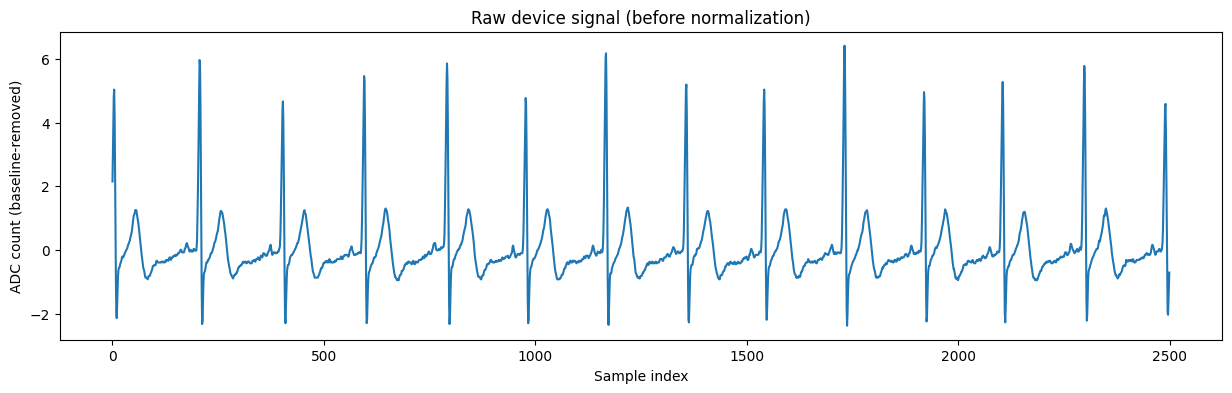

In [204]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 4))
plt.plot(normalized_signal)
plt.title("Raw device signal (before normalization)")
plt.xlabel("Sample index")
plt.ylabel("ADC count (baseline-removed)")
plt.show()